In [1]:

import os
# Make sure you are in scMEDAL_for_scRNAseq dir
os.chdir("/archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq")

# from models.models import train_model_on_named_experiment

In [ ]:

os.getcwd()

## Training Models:

#### Implemented Models:
| Model Class | Model Description | 
|------------|--------------------|  
| `AE` | Autoencoder | 
| `AEC`| Autoencoder Classifier |
| `scMEDAL-FE` | Domain Adversarial Autoencoder |
| `scMEDAL-FEC`| Domain Adversarial Autoencoder Classifier |
| `scMEDAL-RE`| Domain Enhancing Autoencoder Classifier | 

#### Named Experiments:
| Valid Named Experiment | Dataset |  n_clusters | n_pred |
|------------------------|---------|-------------|--------|
| `AML`| Acute Myeloid Leukemia | 19 | 21 |
| `ASD`| Autism Spectrum Disorder | 31 | 17 | 
| `HH` | Healthy Heart | 147 | 13 | 

**Note:** If training on other datasets, the configs will need to be passed in as dictionaries to `model_kwargs` and `train_kwargs`.

`quick` is a boolean flag that can be passed to `train_kwargs` which shortens training to only 1 fold for 3 epochs.

Run models on all 3 datasets with

$python\ run\_scMEDAL\_alldatasets.py$

## Analyzing Models:

When you run a model, it generates the following output directories:
   - /outputs/figures
   - /outputs/latent_space
   - /outputs/saved_models
 
 Inside each of these directories, there is a subdirectory named after the model and its run identifier.
 
 For example: $HH/latent\_space/scmedalfe/run\_crossval\_<run\_name>$

 To analyze your results, copy the corresponding $<run\_name>$ below.

In [2]:

# When you run your model, it outputs the figures, latent_space and saved_models directories, whitin those directories you will find a subdir with the name of the model trained, example: AML/latent_space/scmedalfe/run_crossval_<run_name>
# Please copy the <run_name below> to analyze the results
# Update output paths of the models that you just run

from utils.defaults import HH_OUTPUTS_DIR, HH_EXPERIMENT_NAME
print(f"Loading outputs from {HH_OUTPUTS_DIR}. Please verify that your models output folder is located here before proceeding with the analysis.")
import os
model_folder_dict = {
    "ae":"run_crossval_n_latent_dims-50_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-50_get_cf_batch-False_2025-07-10_07-59",
    "aec":"run_crossval_n_latent_dims-50_layer_units-512-132_n_pred-13_use_batch_norm-True_scaling-min_max_model_type-aec_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_get_cf_batch-False_2025-07-10_11-04",
    "scmedalfe":"run_crossval_loss_gen_weight-1_loss_recon_weight-600_loss_class_weight-1_n_latent_dims-50_layer_units-512-132_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-10_02-47",
    "scmedalfec":"run_crossval_loss_gen_weight-1_loss_recon_weight-2000_loss_class_weight-1_n_latent_dims-50_layer_units-512-132_scaling-min_max_model_type-scmedalfec_batch_size-512_epochs-500_patience-30_sample_size-10000_get_cf_batch-False_2025-07-10_14-36",
    "scmedalre":"run_crossval_loss_recon_weight-110_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-09_22-05",
    # To collect the comparable outputs (see below), you need to run the comparable models in /comparables. 
    "scVI":"run_crossval_n_latent_dims-50_n_layers-2_n_hidden-132_gene_likelihood-zinb_dispersion-gene_scaling-min_max_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_tissue_col-TissueDetail_2025-07-17_10-42",
    "scANVI":"run_crossval_n_latent_dims-50_n_layers-2_n_hidden-132_gene_likelihood-zinb_dispersion-gene_scaling-min_max_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_tissue_col-TissueDetail_2025-07-17_00-40",
    "scanorama":"run_crossval_n_latent_dims-50_scaling-min_max_sample_size-10000_model_type-ae_tissue_col-TissueDetail_2025-07-17_00-46",
    "harmony":"run_crossval_n_latent_dims-50_scaling-min_max_sample_size-10000_model_type-ae_tissue_col-TissueDetail_2025-07-17_00-40",
    "SAUCIE":"run_crossval_n_latent_dims-50_layers-512-132-50_lambda_b-0.0_lambda_c-0.0_lambda_d-0.0_learning_rate-0.0_scaling-min_max_batch_size-512_epochs-50_patience-30_sample_size-10000_model_type-ae_tissue_col-TissueDetail_2025-07-17_10-40",


    }

model_paths = {k:os.path.join(HH_OUTPUTS_DIR, "latent_space", HH_EXPERIMENT_NAME,k, v) for k, v in model_folder_dict.items()}




OUTPUTS_DIR: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs
Loading outputs from /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/HH. Please verify that your models output folder is located here before proceeding with the analysis.


##### Step 1: Import the analysis class and initialize it

In [5]:

import analysis.analysis as aa

# analysis_name = "HH_default_500_v1.3"
analysis_name = "HH_default_500"



hh = aa.HHAnalysis(model_folder_dict, analysis_name)

##### Step 2: Compile clustering scores calculated after training the models

In [4]:


res= hh.clustering_scores(model_folder_dict)
# You can now inspect or export `clustering_results` as needed
# Note: if you only run 1 fold, you will see NAN in CI entries
res

[WARN] scVI: config.json not found: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/HH/saved_models/log_transformed_3000hvggenes/scVI/run_crossval_n_latent_dims-50_n_layers-2_n_hidden-132_gene_likelihood-zinb_dispersion-gene_scaling-min_max_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_tissue_col-TissueDetail_2025-07-17_10-42/configs.json  using single-model format (AE will default to PCA format if present)
[WARN] scANVI: config.json not found: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/HH/saved_models/log_transformed_3000hvggenes/scANVI/run_crossval_n_latent_dims-50_n_layers-2_n_hidden-132_gene_likelihood-zinb_dispersion-gene_scaling-min_max_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_tissue_col-TissueDetail_2025-07-17_00-40/configs.json  using single-model format (AE will default to PCA f

batch                                                         \
                1/db                        ch                   silhouette   
                mean CI_lower CI_upper    mean CI_lower CI_upper       mean   
dataset_type                                                                  
X_pca_test      0.14     0.13     0.14   47.25    46.55    47.96      -0.18   
ae_latent_test  0.13     0.13     0.14   50.23    33.88    66.59      -0.17   
SAUCIE          0.06     0.05     0.07   15.74     6.10    25.37      -0.45   
aec             0.10     0.09     0.11   29.21    21.98    36.45      -0.32   
harmony         0.11     0.06     0.15   31.92    11.70    52.13      -0.21   
scANVI          0.06     0.06     0.07    8.53     7.39     9.68      -0.55   
scVI            0.06     0.05     0.06    5.23     4.56     5.90      -0.50   
scanorama       0.12     0.10     0.14   48.17    45.76    50.59      -0.21   
scmedalfe       0.10     0.10     0.11   28.55    14.96    42.14      -0.21   
scmedalfec      0.12     0.11     0.12   13.87    13.32    14.42      -0.20   
scmedalre       0.42     0.37     0.47  333.73   239.78   427.68       0.10   

                                 celltype                                      \
                                     1/db                         ch            
               CI_lower CI_upper     mean CI_lower CI_upper     mean CI_lower   
dataset_type                                                                    
X_pca_test        -0.19    -0.17     0.40     0.38     0.42   691.12   678.39   
ae_latent_test    -0.19    -0.16     0.38     0.34     0.41   796.46   698.29   
SAUCIE            -0.52    -0.37     0.20     0.13     0.27  2354.75   459.41   
aec               -0.37    -0.27     0.54     0.47     0.62  2473.06  1943.55   
harmony           -0.28    -0.15     0.27     0.13     0.41   875.22   639.57   
scANVI            -0.59    -0.50     0.65     0.58     0.72  3510.81  2787.12   
scVI              -0.55    -0.45     0.55     0.45     0.64  2010.52  1848.34   
scanorama         -0.27    -0.16     0.40     0.38     0.42   748.77   674.34   
scmedalfe         -0.23    -0.19     0.37     0.35     0.39   762.33   612.55   
scmedalfec        -0.21    -0.18     0.40     0.39     0.41   679.06   640.22   
scmedalre          0.07     0.13     0.20     0.18     0.21   268.98   207.41   

                                                      
                        silhouette                    
               CI_upper       mean CI_lower CI_upper  
dataset_type                                          
X_pca_test       703.84       0.15     0.15     0.15  
ae_latent_test   894.64       0.13     0.12     0.14  
SAUCIE          4250.10      -0.06    -0.14     0.01  
aec             3002.56       0.32     0.29     0.36  
harmony         1110.87       0.13     0.10     0.15  
scANVI          4234.49       0.32     0.26     0.39  
scVI            2172.70       0.22     0.16     0.28  
scanorama        823.20       0.18     0.14     0.22  
scmedalfe        912.10       0.10     0.08     0.12  
scmedalfec       717.90       0.14     0.14     0.15  
scmedalre        330.54      -0.05    -0.07    -0.04

##### Step 3: Generate and save the UMAP plots

In [5]:

# This typically loads latent representations stored after training and creates UMAPs for each model
processors = hh.umap(model_folder_dict, types=["train"], splits=[1])
processors

Reading inputs and latent paths ..
umap saved to /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/HH/compare_models/log_transformed_3000hvggenes/HH_default_500/umap_19batches_seed_5
Computing UMAP projections...


Processing input prefix: 0 train_1
Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/HealthyHeart_data/log_transformed_3000hvggenes/splits/split_1/train


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



Scenario 2: Processing input subset batches (train_1)

Processing input sample
Computing UMAP on 41544 cells * 3000 features, using 'X_pca'
UMAP shape: (41544, 2)

Scenario 4: Processing latent subset batches (train_1)


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



Processing: ae_latent_train_1
Computing UMAP on 41544 cells * 50 features, using 'X'
UMAP shape: (41544, 2)


...


Processing: scanorama_latent_train_1
Computing UMAP on 41544 cells * 50 features, using 'X'
UMAP shape: (41544, 2)


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



Processing: harmony_latent_train_1
Computing UMAP on 41544 cells * 50 features, using 'X'
UMAP shape: (41544, 2)


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



Processing: SAUCIE_latent_train_1
Computing UMAP on 41544 cells * 50 features, using 'X'
UMAP shape: (41544, 2)


In [6]:
# Visualize the generated umap images for scmedalre 
from IPython.display import HTML, display
import glob

outputs_path = os.path.join(hh.paths.outputs_path, analysis_name)
# Make sure this path leads to the stored umap figures
figs_list    = glob.glob(outputs_path + "/*umap*/*plots_axis/*umap*scmedalre*")

html = (
    "<div style='display:flex; flex-wrap:wrap; gap:10px;'>"
    + "".join(f"<img src='{fig}' style='max-width:500px;'>" for fig in figs_list)
    + "</div>"
)
display(HTML(html))

##### Step 4: Run genomaps on a subsample of the input data along with reconstructions from the scmedalfe and scmedalre models. 

Visualize selected batches to assess batch-specific effects in the reconstructed spaces, including conterfactual projections from scmedalre.

In [4]:

# Run genomaps on a subsample input+scmedalfe recon +scmedal re recon for different batches
# Tissues: Left ventricle and Septum (myeloid and endothelial). Selected the following batches because they come fro the same protocol
batches = ["HCAHeart7850545", "HCAHeart7888922", "HCAHeart7833854", "HCAHeart7702880"]



# for this genomap config, you need to compute first the reconstructions from scMEDAL-FE and scMEDAL-RE
selected_models = {k: model_folder_dict[k] for k in ("scmedalfe", "scmedalre")}
gfd = hh.genomap(selected_models,
                            n_batches = 147,
                            num_iter = 200, # for quick test, otherwise 100
                            cell_id_col = "_index",
                            gene_index_col = "_index",
                            celltype = ["Myeloid", "Endothelial"],#, "Fibroblast", "Pericytes"],
                            batches=batches,
                            models=['scmedalre'],#if add_inputs_fe=True-> scmedalfe+ inputs are used for genomap creation by default, no need to add the to the list, 
                            types=["train"], 
                            splits=[1],
                            add_inputs_fe= True,
                            extra_recon = "fe",
                            min_val = -2,
                            max_val = 6)#,issparse=True )


Looking for outputs paths for the following models:dict_keys(['scmedalfe', 'scmedalre'])
Created df with input and recon paths


Initialized genomap pipeline ..
genomaps saved to /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/HH/compare_models/log_transformed_3000hvggenes/HH_default_500/genomap 
Run genomap pipeline for:  ['train'] [1] ['scmedalre']
train 1 scmedalre
Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/data/HH_data/log_transformed_3000hvggenes/splits/split_1/train
Batches selected for plotting: ['HCAHeart7850545', 'HCAHeart7888922', 'HCAHeart7833854', 'HCAHeart7702880']


Sampling adata  multibatch from original data and recons..
Saving to adata multibatch directory: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/HH/compare_models/log_transformed_3000hvggenes/HH_default_500/genomap/CMmultibatch_300_cells_per_batch_147batches_Myeloid_Endoth

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Completed subsampling of adata_multibatch
adata_mb AnnData object with n_obs × n_vars = 44700 × 2916
    obs: 'Unnamed: 0.1', 'Unnamed: 0', 'Age', 'AgeBin', 'DeathType', 'DonorID', 'Gender', 'Organ', 'Race', 'SampleType', 'Source', 'Tissue', 'TissueDetail', '_index', 'celltype', 'protocol', 'sampleID', 'n_genes', 'batch', 'original_index', 'recon_prefix'
    var: 'Unnamed: 0', 'gene_ids', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_names'
cells selected from the following batches ['HCAHeart7850545', 'HCAHeart7888922', 'HCAHeart7833854', 'HCAHeart7702880']
b'CAGATCACAAAGTGCG-1-HCAHeart7850545' comes from batch HCAHeart7850545
b'CACTCCAGTCAACATC-1-HCAHeart7850545' comes from batch HCAHeart7850545
b'CAGCTAATCCGGCACA-1-HCAHeart7888922' comes from batch HCAHeart7888922
b'TCGGGACAGTACGTAA-1-HCAHeart7888922' comes from batch HCAHeart7888922
b'AGTGTCATCTTACCGC-1-HCAHeart7833854' comes from batch HCAHeart7833854
b'GTCACGGCACACTGCG-1-HCAHeart7833854' comes fro

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Input does not contain NaNs
subset_input_z_scores shape: (44700, 2916)


...

created plot with no gene labels
plotting small panel for b'GCTGCGAGTGCAACGA-1-HCAHeart7702880' with original batch HCAHeart7702880 and celltype Myeloid, n recons: 6
Saved gene std across batches  to: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/HH/compare_models/log_transformed_3000hvggenes/HH_default_500/genomap/genomap_plots/Myeloid/singlecell_gene_std_acrossbatches/genomap_b'GCTGCGAGTGCAACGA-1-HCAHeart7702880'_std_10topvariablegenesacrossbatches.csv


plotting big panel for single cell b'GCTGCGAGTGCAACGA-1-HCAHeart7702880' from original batch HCAHeart7702880 and celltype Myeloid, n recons: 149


/endosome/archive/bioinformatics/DLLab/src/AixaAndrade/gitfront/dev2/scMEDAL_for_scRNAseq/utils/genomaps_utils.py:1032: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 0.9, 0.97])


created plot with no gene labels
plotting small panel for b'ACTGTCCTCCGCGGTA-1-HCAHeart7702880' with original batch HCAHeart7702880 and celltype Endothelial, n recons: 6
Saved gene std across batches  to: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/HH/compare_models/log_transformed_3000hvggenes/HH_default_500/genomap/genomap_plots/Endothelial/singlecell_gene_std_acrossbatches/genomap_b'ACTGTCCTCCGCGGTA-1-HCAHeart7702880'_std_10topvariablegenesacrossbatches.csv


plotting big panel for single cell b'ACTGTCCTCCGCGGTA-1-HCAHeart7702880' from original batch HCAHeart7702880 and celltype Endothelial, n recons: 149


/endosome/archive/bioinformatics/DLLab/src/AixaAndrade/gitfront/dev2/scMEDAL_for_scRNAseq/utils/genomaps_utils.py:1032: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 0.9, 0.97])


created plot with no gene labels


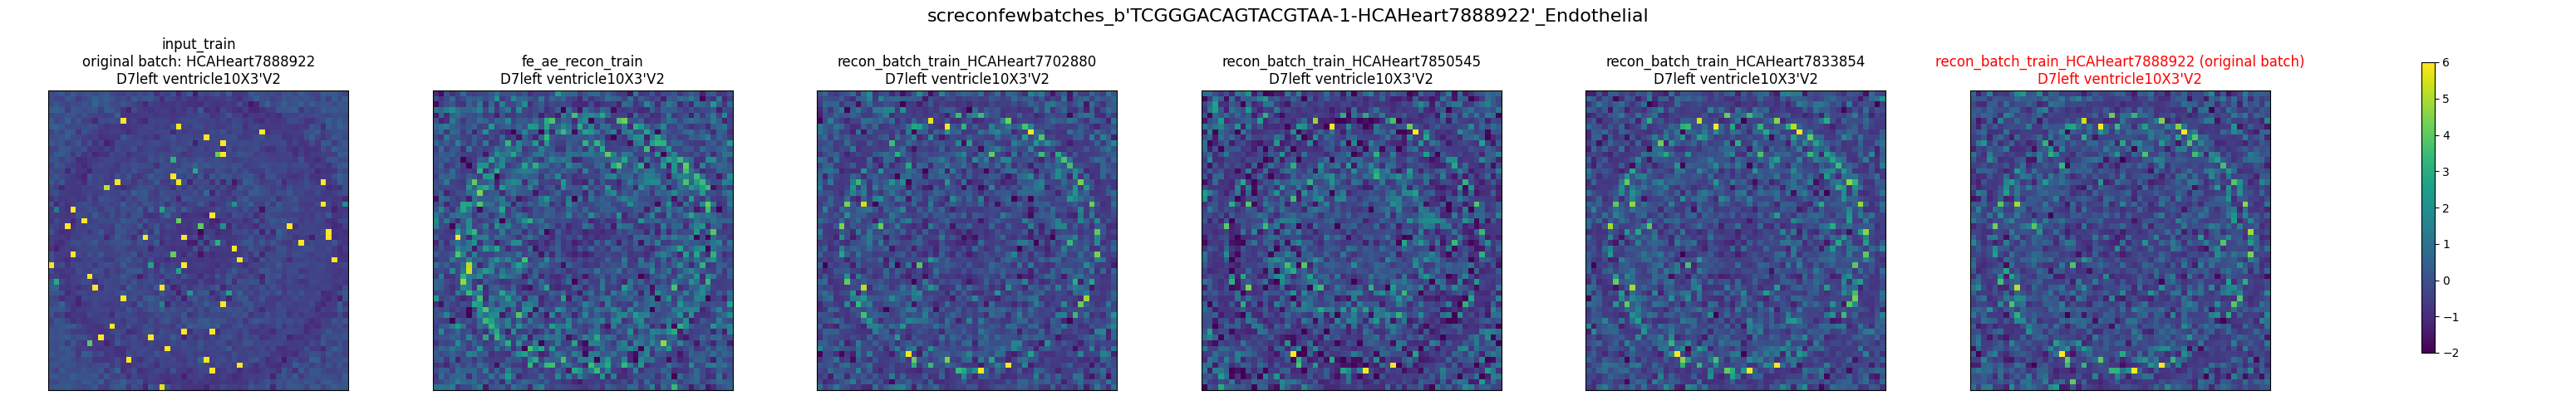

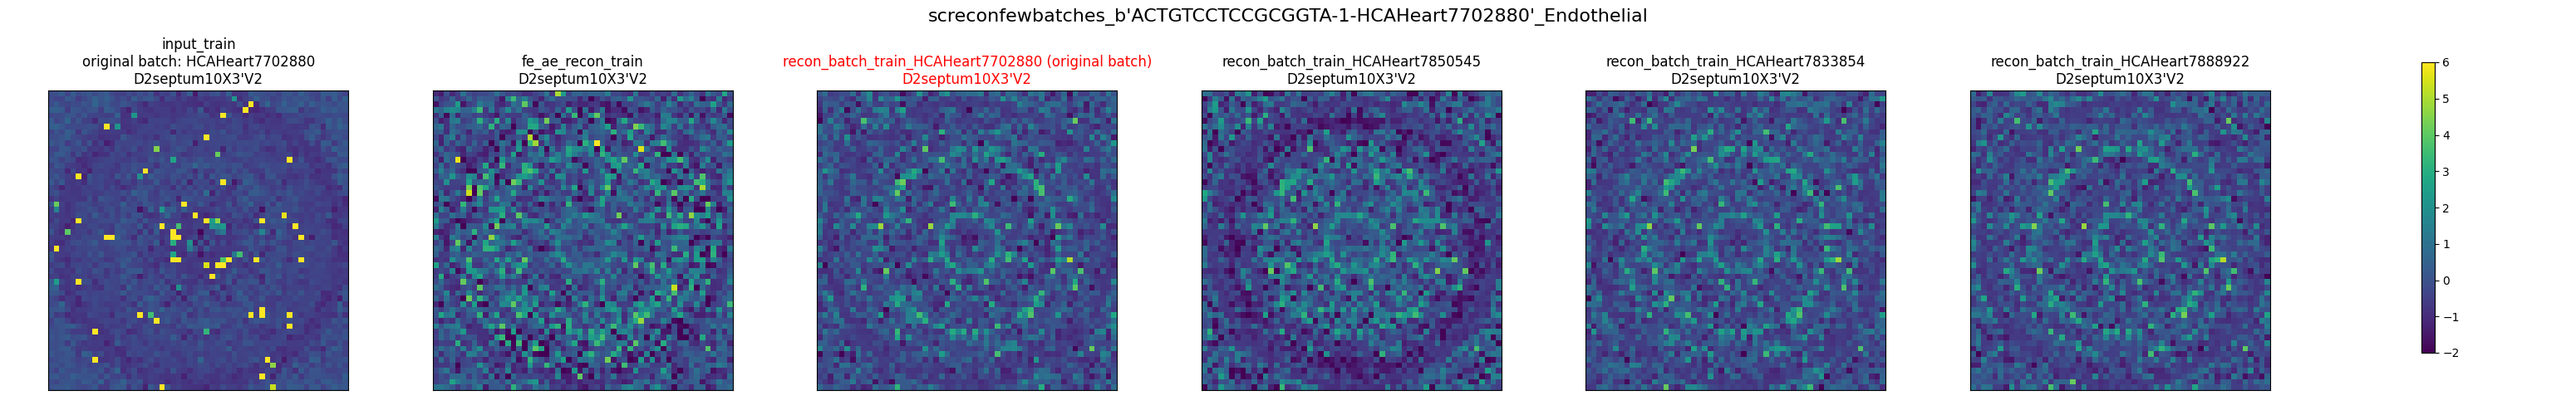

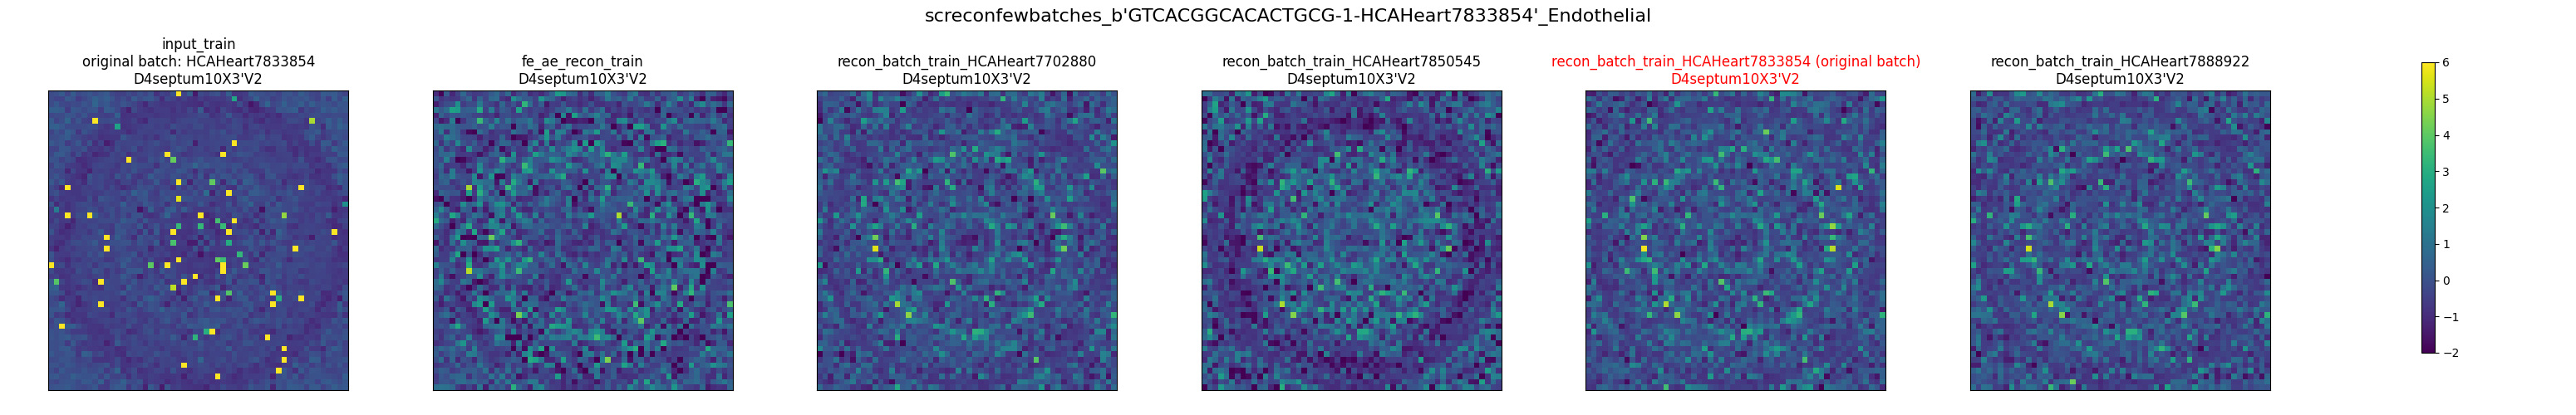

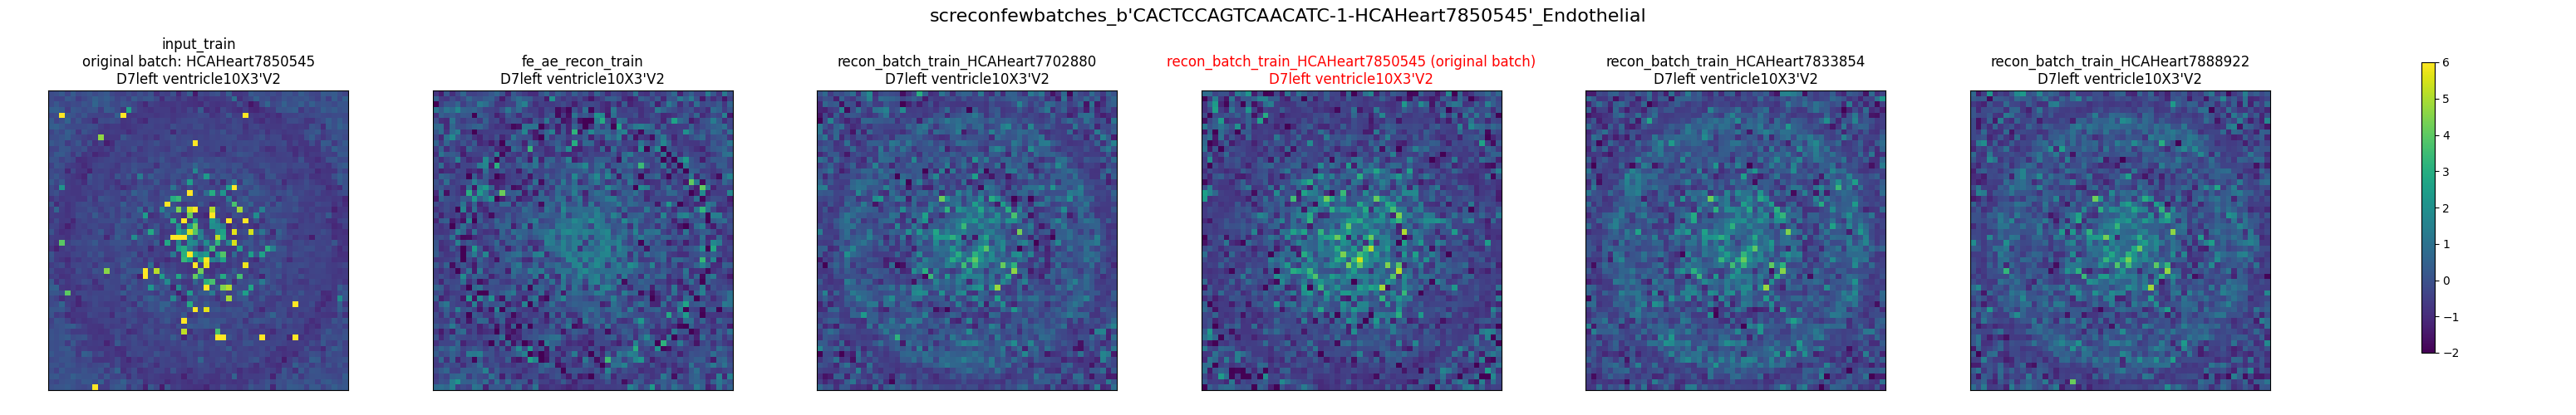

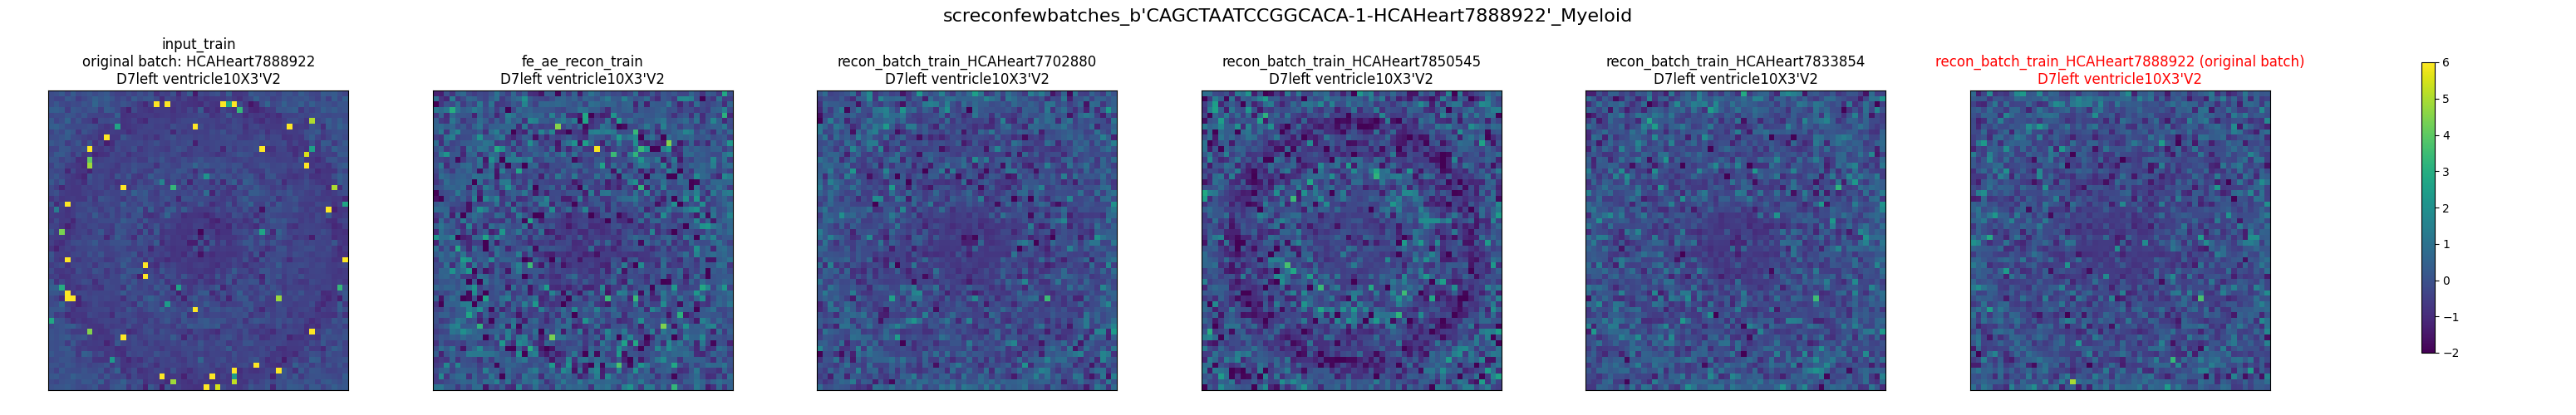

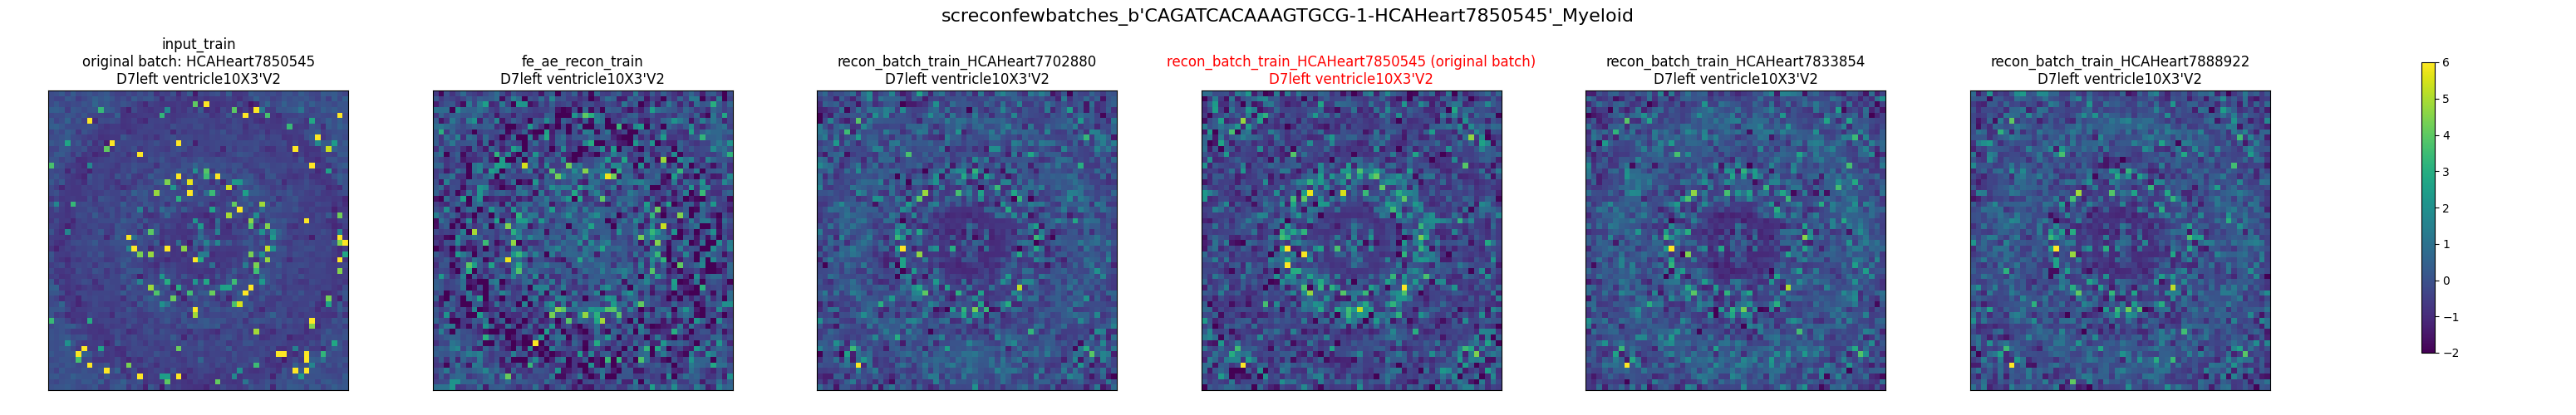

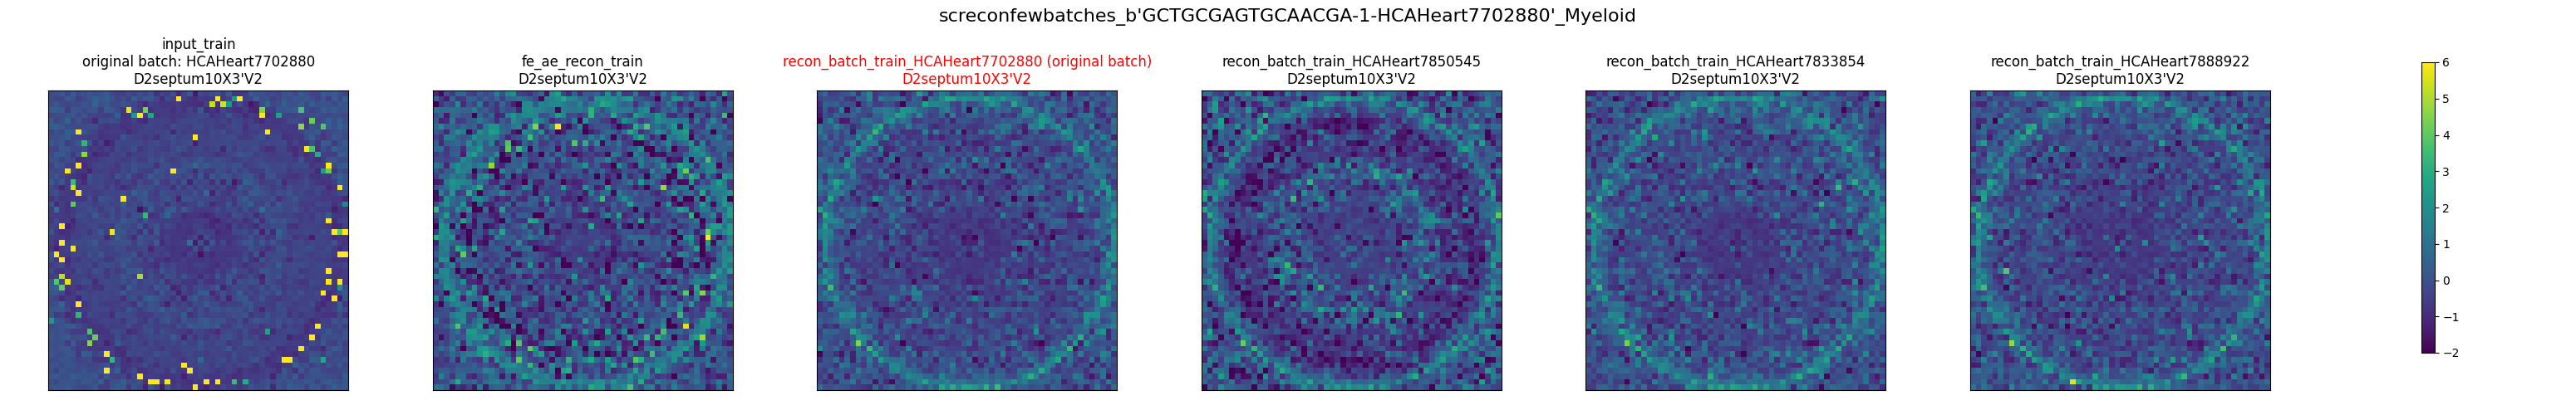

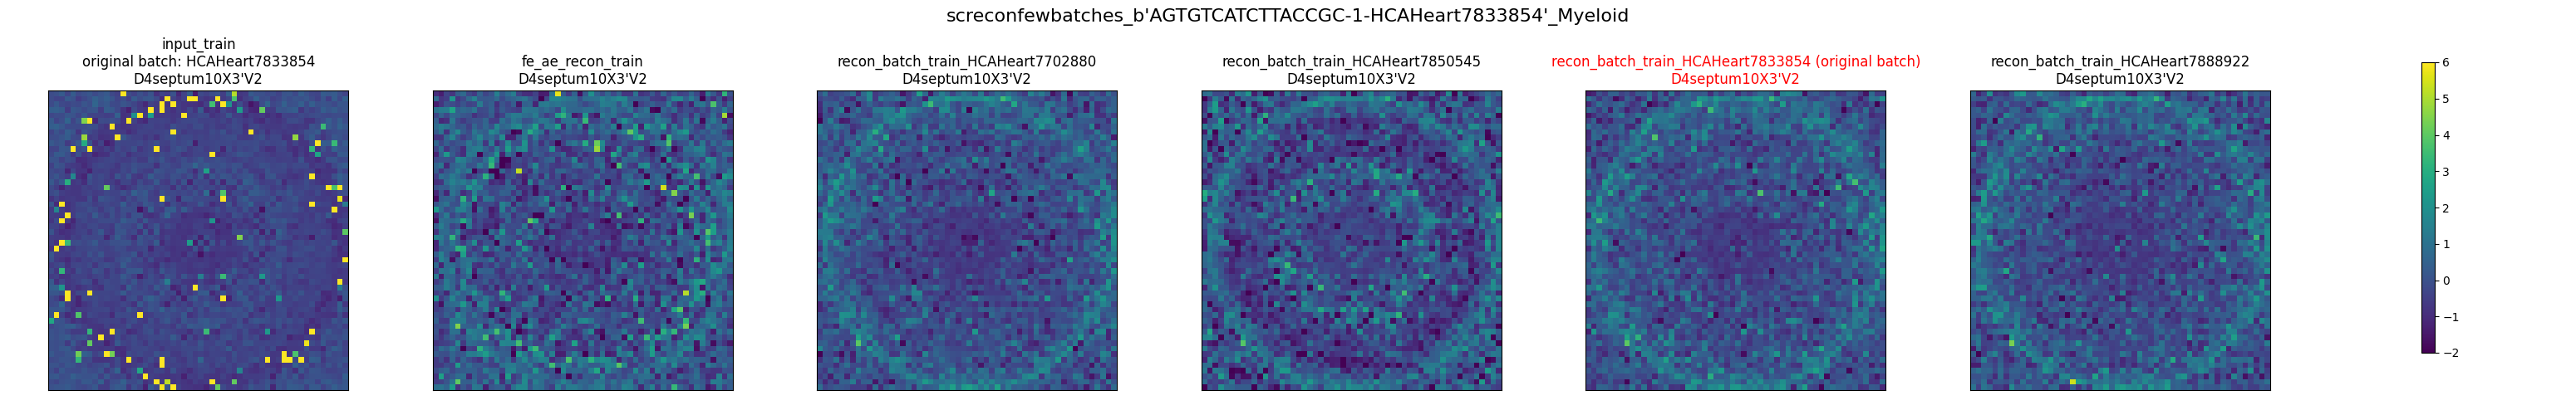

In [7]:
# View genomap images
from IPython.display import Image, display


genomap_path = os.path.join(
    hh.paths.outputs_path, 
    analysis_name, 
    "genomap", 
    "genomap_plots"
)
# Make sure this path leads to the stored genomap figures
figs_list = glob.glob(
    os.path.join(genomap_path, "*", "*genomap_plots_scfewbatches_nogenelabels", "*")
)

# Show all figures
for fig in figs_list:
    display(Image(filename=fig))

## Run the Mixed Effects Classifier (MEC) on latent spaces generated by scmedalfe and scmedalre.

Classification target: 6 tissues 

Run $python\ mec\_hh.py$

In [ ]:
# Now get a summary table of all mec results
from utils.compare_results_utils import get_all_mec_metrics
df,_ = get_all_mec_metrics(HH_OUTPUTS_DIR,HH_EXPERIMENT_NAME, split='test')
df